# Financials

We now take together all the individual steps we have taken to calculate the Expected damage distribution for a certain portfolio to find its fair price. 

In [1]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.append('../src')

from utils.track import track_interpolation, cyclone_velocity, cyclone_bearing


To do so we first generate a ensemble of 1000 syntethic years with cyclone tracks. We then combine each of those individual tracks to calculate a loss for individual storms yielding a total loss per yer. Note that we here expect for simplicity that the same portfolio can be hit twice by a storm in a year. 


In [3]:
from probabilistic import SyntheticTCCatalog

model = SyntheticTCCatalog(basin='al', grid_size=2.0, max_hours=360, verbose=False)
model.fit("/Users/wirths/Documents/Private/NatCat/data/raw")


SyntheticTCCatalog(basin='al', grid_size=2.0, max_hours=360, time_step=3.0, status=fitted)

In [4]:
from hazards.tropical_cyclone import TropicalCycloneHazard
from vulnerability import WindVulnerability
from loss_model import LossCalculator


#Set portfolio: 
from preprocessing.tropical_cyclone import get_country_exposure_via_api, convert_to_loss_model_format
portfolio = get_country_exposure_via_api("USA", [24.5, 32.0, -87.6, -80.0])
portfolio = convert_to_loss_model_format(portfolio)

# Dataflow across a year: 
num_years = 100

# vulnerbility 
vulnerability = WindVulnerability()

losses_per_year = []
for i in tqdm(range(num_years), desc="Simulating years"):
    synthetic_tracks = model.generate(n_years=1)

    #Get amount of stroms per year
    num_storms = len(synthetic_tracks['storm_id'].unique())
    
    #Now we isolate a syntehtic storm 
    losses_this_year = []
    for storm_id in synthetic_tracks['storm_id'].unique():
        storm_data = synthetic_tracks[synthetic_tracks['storm_id'] == storm_id].copy()

        # Derive timestamps from hour counter so interpolation works regardless of kernel state
        storm_data['timestamp'] = pd.Timestamp('1900-01-01') + pd.to_timedelta(storm_data['hour'] * model.time_step, unit='h')

        # Track interpolation for better spatial resolution in the wind field
        storm_data = track_interpolation(storm_data, time_step='30min')
        storm_data = cyclone_velocity(storm_data)
        storm_data = cyclone_bearing(storm_data)

        hazard = TropicalCycloneHazard(storm_data)
        loss = LossCalculator(hazard, vulnerability)
        loss.calculate_portfolio_loss(portfolio)
        losses_this_year.append(loss.total_loss)
    losses_per_year.append(sum(losses_this_year))


Initializing CLIMADA Data Client...
Downloading/Loading USA exposure data (this may take a moment)...
Filtering for subregion: [24.5, 32.0, -87.6, -80.0]...


Simulating years: 100%|██████████| 100/100 [05:47<00:00,  3.47s/it]


(array([86.,  3.,  3.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.00000000e+00, 2.31691480e+09, 4.63382961e+09, 6.95074441e+09,
        9.26765922e+09, 1.15845740e+10, 1.39014888e+10, 1.62184036e+10,
        1.85353184e+10, 2.08522332e+10, 2.31691480e+10, 2.54860629e+10,
        2.78029777e+10, 3.01198925e+10, 3.24368073e+10, 3.47537221e+10,
        3.70706369e+10, 3.93875517e+10, 4.17044665e+10, 4.40213813e+10,
        4.63382961e+10, 4.86552109e+10, 5.09721257e+10, 5.32890405e+10,
        5.56059553e+10, 5.79228701e+10, 6.02397849e+10, 6.25566997e+10,
        6.48736145e+10, 6.71905293e+10, 6.95074441e+10, 7.18243589e+10,
        7.41412738e+10, 7.64581886e+10, 7.87751034e+10, 8.10920182e+10,
        8.34089330e+10, 8.57258478e+10, 8.80427626e+10, 9.03596774e+

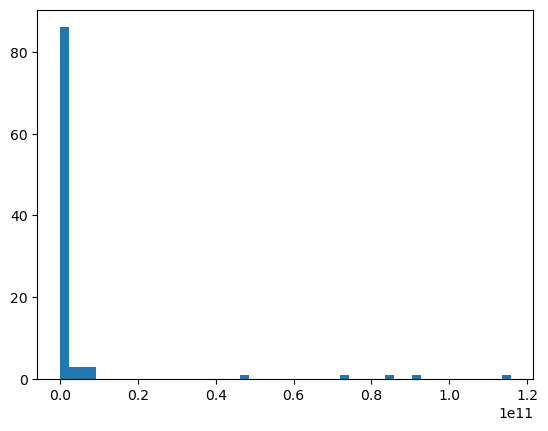

In [23]:
# Make historgam of losses per year
plt.hist(losses_per_year, bins=50)

In [36]:
losses_per_year

[21620237.59613212,
 10818238.974563126,
 5413864591.283294,
 0.0,
 0.0,
 0.0,
 0.0,
 113506468.41996074,
 307955466.92443544,
 0.0,
 91831002668.7369,
 1346796.1447968811,
 74029686.69856425,
 4191635394.156354,
 72342057445.81194,
 11510750.567322174,
 3799231770.7871895,
 22503079.30960618,
 261689545.33711523,
 2452678.932853312,
 0.0,
 3723910.891108191,
 192122129.43131816,
 0.0,
 7896616239.271703,
 32815727.947556134,
 0.0,
 123987754.23634586,
 203572139.70492852,
 1487501404.4632895,
 481056762.5367261,
 0.0,
 2755268.0626551746,
 245351937.3595166,
 0.0,
 556188570.0487252,
 214639042.63017362,
 42601432.95173968,
 1287903.536993101,
 0.0,
 0.0,
 0.0,
 0.0,
 9102489650.414322,
 0.0,
 331598940.19682395,
 20782423.778877307,
 0.0,
 5924.494802730678,
 0.0,
 19262960.956559103,
 0.0,
 0.0,
 46473080.032461286,
 1329566828.0449967,
 0.0,
 0.0,
 57164286.87905067,
 71635779.84791017,
 0.0,
 173198668.23507148,
 0.0,
 0.0,
 85044791827.7961,
 483359001.83876514,
 0.0,
 59347405.0

In [5]:
import time

# --- Data sizes ---
print(f"Portfolio size: {len(portfolio)} locations")
print(f"Columns: {list(portfolio.columns)}")
print()

# Generate one year of storms for profiling
synthetic_tracks = model.generate(n_years=1)
storm_ids = synthetic_tracks['storm_id'].unique()
print(f"Storms this year: {len(storm_ids)}")

# Pick one storm and measure each step
storm_data_raw = synthetic_tracks[synthetic_tracks['storm_id'] == storm_ids[0]].copy()
print(f"Raw track points (one storm): {len(storm_data_raw)}")

# Step 1: timestamp + interpolation + vel/bearing
t0 = time.time()
storm_data_raw['timestamp'] = pd.Timestamp('1900-01-01') + pd.to_timedelta(storm_data_raw['hour'] * model.time_step, unit='h')
storm_data = track_interpolation(storm_data_raw, time_step='30min')
storm_data = cyclone_velocity(storm_data)
storm_data = cyclone_bearing(storm_data)
t_interp = time.time() - t0
print(f"Interpolated track points: {len(storm_data)}")
print(f"Step 1 (interp + vel + bearing): {t_interp*1000:.1f} ms")

# Step 2: hazard computation
t0 = time.time()
hazard = TropicalCycloneHazard(storm_data)
coordinates = portfolio[['latitude', 'longitude']].to_numpy()
intensity = hazard.compute_intensity(coordinates)
t_hazard = time.time() - t0
print(f"Step 2 (hazard/wind field):       {t_hazard*1000:.1f} ms")

# Step 3: vulnerability + loss
t0 = time.time()
loss = LossCalculator(hazard, vulnerability)
loss.calculate_portfolio_loss(portfolio)
_ = loss.total_loss
t_loss = time.time() - t0
print(f"Step 3 (vulnerability + loss):     {t_loss*1000:.1f} ms")

# Step 4: full generate() call timing
t0 = time.time()
_ = model.generate(n_years=1)
t_gen = time.time() - t0
print(f"\nStep 4 (model.generate n_years=1): {t_gen*1000:.1f} ms")

# Step 5: generate 100 years at once
t0 = time.time()
_ = model.generate(n_years=100)
t_gen100 = time.time() - t0
print(f"Step 5 (model.generate n_years=100): {t_gen100*1000:.1f} ms")

print(f"\n--- Summary per storm (estimated) ---")
print(f"  Interpolation: {t_interp*1000:.1f} ms")
print(f"  Wind field:    {t_hazard*1000:.1f} ms")
print(f"  Loss calc:     {t_loss*1000:.1f} ms (includes wind field again)")
print(f"  Generation:    {t_gen*1000/len(storm_ids):.1f} ms/storm")


Portfolio size: 12201 locations
Columns: ['location_id', 'latitude', 'longitude', 'tiv', 'construction']

Storms this year: 14
Raw track points (one storm): 27
Interpolated track points: 157
Step 1 (interp + vel + bearing): 1.5 ms
Step 2 (hazard/wind field):       120.0 ms
Step 3 (vulnerability + loss):     93.9 ms

Step 4 (model.generate n_years=1): 58.4 ms
Step 5 (model.generate n_years=100): 4901.9 ms

--- Summary per storm (estimated) ---
  Interpolation: 1.5 ms
  Wind field:    120.0 ms
  Loss calc:     93.9 ms (includes wind field again)
  Generation:    4.2 ms/storm
